In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned data
df = pd.read_csv("cleaned_tmdb_data.csv")

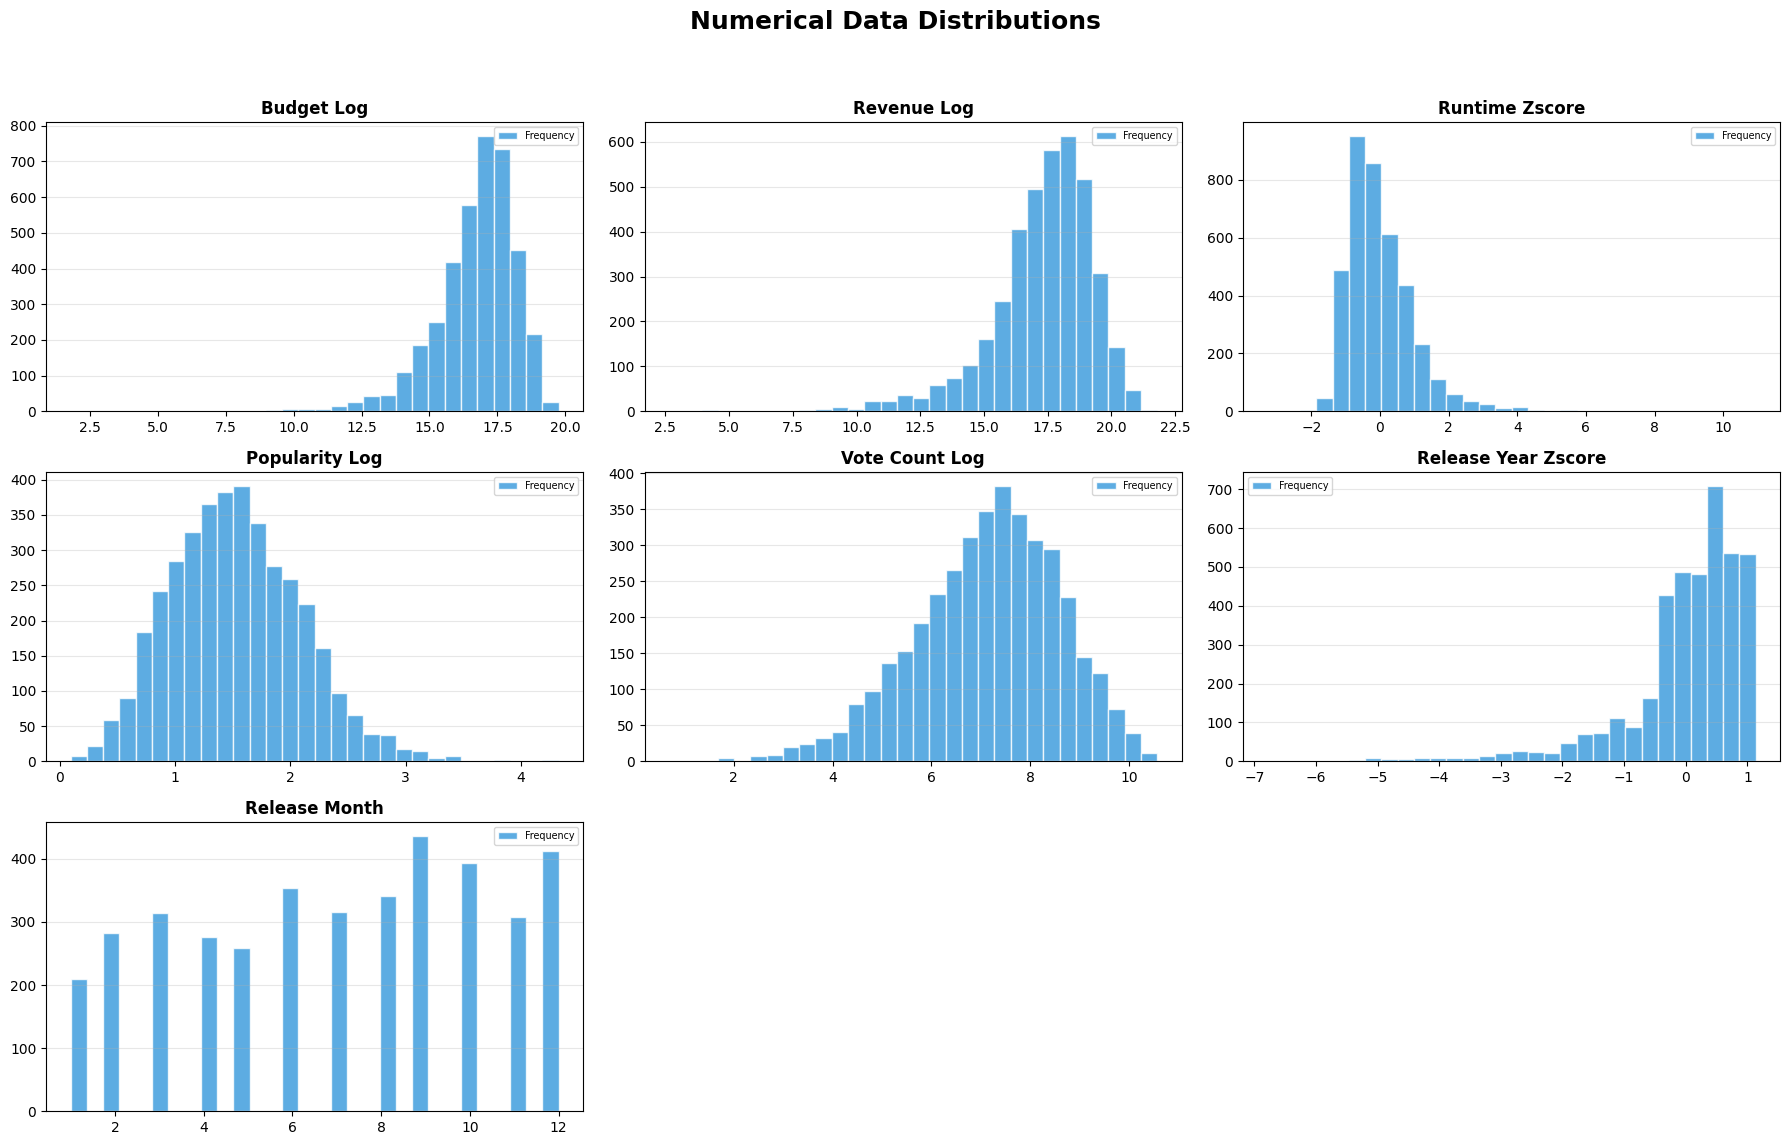

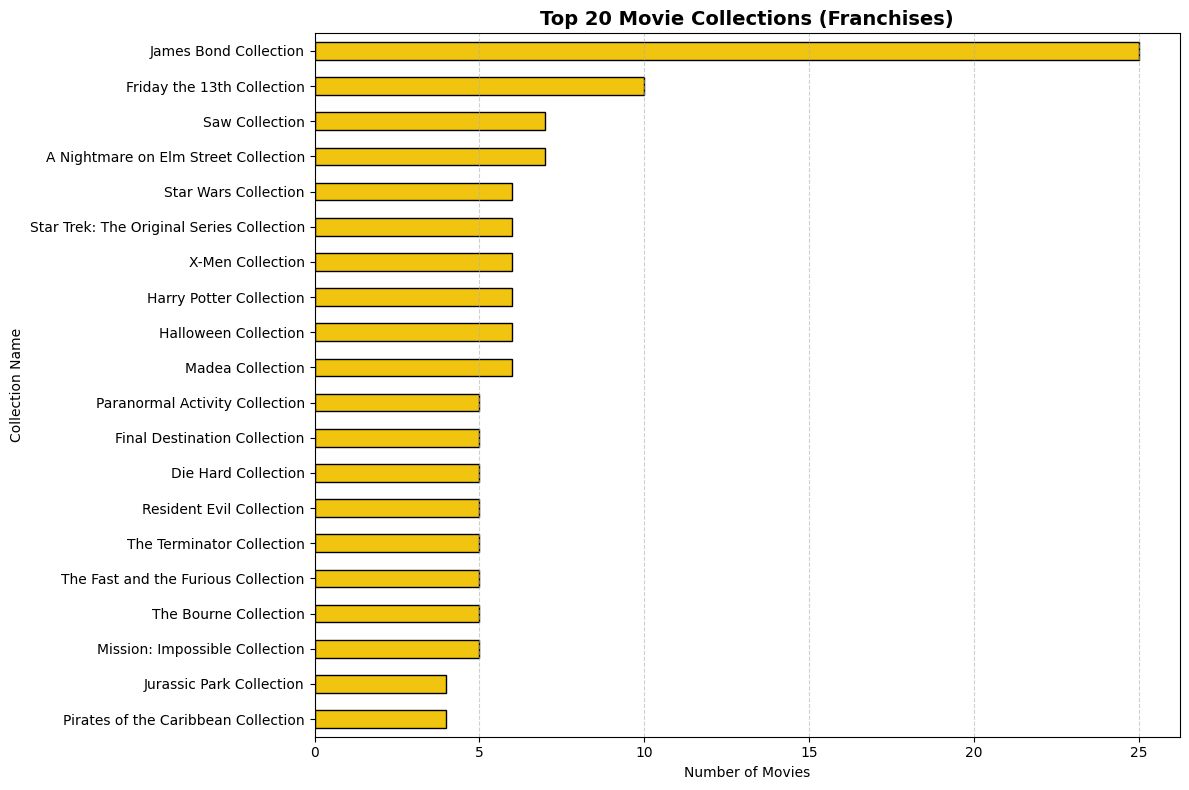

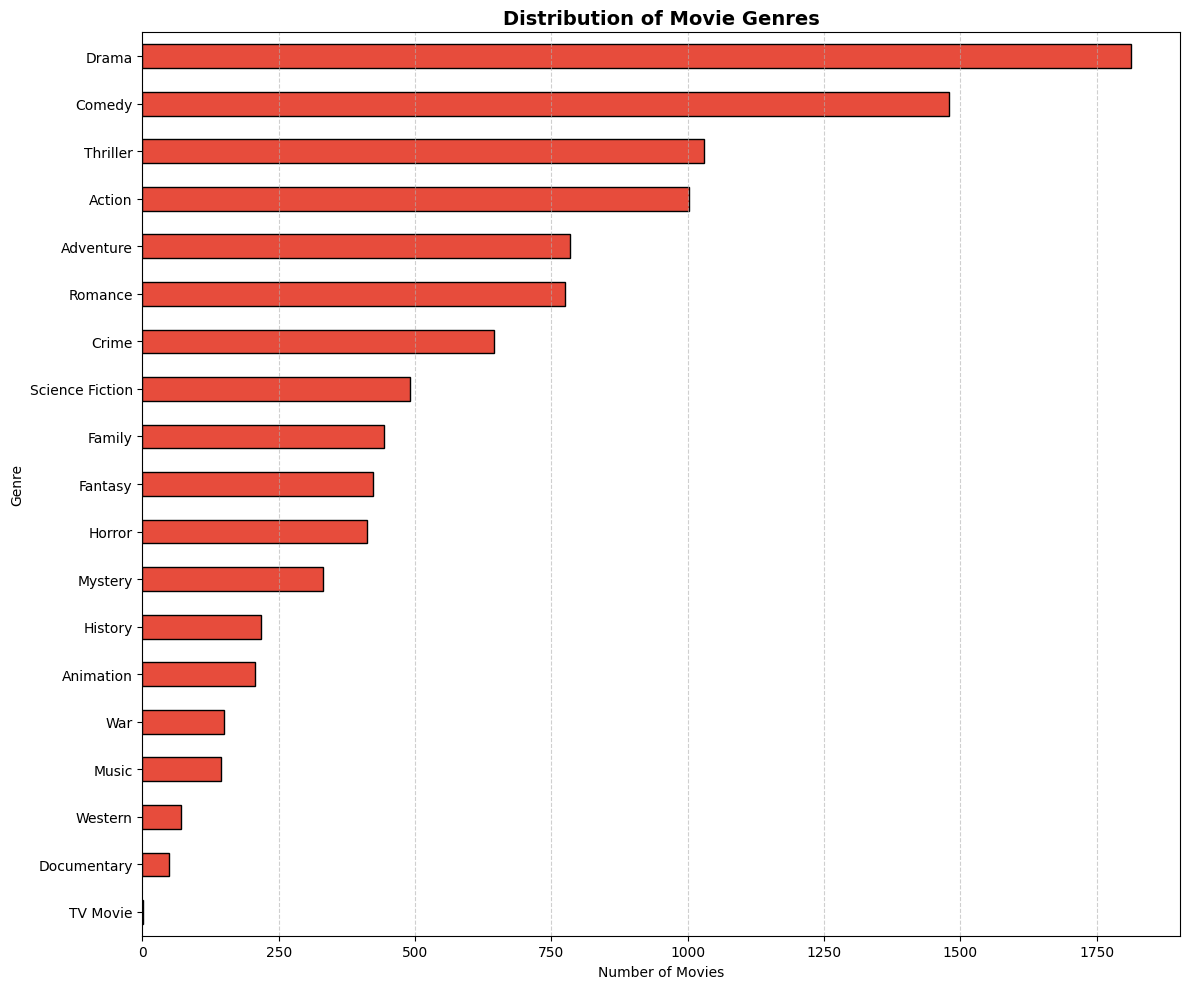

In [9]:
num_cols = ['budget_log', 'revenue_log', 'runtime_zscore', 
            'popularity_log', 'vote_count_log', 'release_year_zscore', 'release_month']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
fig.suptitle('Numerical Data Distributions', fontsize=18, fontweight='bold', y=0.98)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, color='#3498db', edgecolor='white', alpha=0.8, label='Frequency')
    
    axes[i].set_title(f'{col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[i].legend(fontsize='x-small') 
    axes[i].grid(axis='y', alpha=0.3)

for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('numerical_distributions.png')

plt.figure(figsize=(12, 8))
collection_counts = df[df['collection'] != 'Standalone']['collection'].value_counts().head(20)

collection_counts.sort_values().plot(kind='barh', color='#f1c40f', edgecolor='black')
plt.title('Top 20 Movie Collections (Franchises)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Movies')
plt.ylabel('Collection Name')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('top_collections.png')

plt.figure(figsize=(12, 10))
genre_counts = df['genres_cleaned'].str.split('|').explode().value_counts()
genre_counts.sort_values().plot(kind='barh', color='#e74c3c', edgecolor='black')

plt.title('Distribution of Movie Genres', fontsize=14, fontweight='bold')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('genre_distribution.png')



In [ ]:
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("STATISTICAL INFERENCE - TMDB MOVIES")
print("="*60)

df = pd.read_csv('cleaned_tmdb_data.csv')

df_financial = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()

print(f"\n Dataset: {len(df_financial)} movies with budget & revenue > 0\n")

print("-"*60)
print("1  CONFIDENCE INTERVALS (95%)")
print("-"*60)

def confidence_interval(data, confidence=0.95):
    """Calculate confidence interval for mean"""
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)
    margin = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean - margin, mean + margin

revenue = df_financial['revenue'].dropna()
ci_revenue = confidence_interval(revenue)
print(f"\n Mean Revenue:")
print(f"   Sample Mean: ${revenue.mean():,.0f}")
print(f"   95% CI: [${ci_revenue[0]:,.0f}, ${ci_revenue[1]:,.0f}]")

budget = df_financial['budget'].dropna()
ci_budget = confidence_interval(budget)
print(f"\n Mean Budget:")
print(f"   Sample Mean: ${budget.mean():,.0f}")
print(f"   95% CI: [${ci_budget[0]:,.0f}, ${ci_budget[1]:,.0f}]")

votes = df_financial['vote_average'].dropna()
ci_votes = confidence_interval(votes)
print(f"\n Mean Vote Average:")
print(f"   Sample Mean: {votes.mean():.2f}")
print(f"   95% CI: [{ci_votes[0]:.2f}, {ci_votes[1]:.2f}]")

print("\n" + "-"*60)
print("2  HYPOTHESIS TESTS")
print("-"*60)

print("\n H1: Action movies have higher budgets than Drama movies")
print("   H0: Mean budget(Action) = Mean budget(Drama)")
print("   H1: Mean budget(Action) > Mean budget(Drama)")

action_budgets = df_financial[df_financial['genres'].str.contains('Action', na=False, case=False)]['budget']
drama_budgets = df_financial[df_financial['genres'].str.contains('Drama', na=False, case=False)]['budget']

t_stat, p_value = stats.ttest_ind(action_budgets, drama_budgets, alternative='greater')
print(f"\n   Action movies (n={len(action_budgets)}): Mean = ${action_budgets.mean():,.0f}")
print(f"   Drama movies (n={len(drama_budgets)}): Mean = ${drama_budgets.mean():,.0f}")
print(f"   t-statistic: {t_stat:.3f}")
print(f"   p-value: {p_value:.6f}")
print(f"    Reject H0" if p_value < 0.05 else "   ❌ Fail to reject H0" if p_value < 0.10 else "   ❌ Fail to reject H0" )

print("\n H2: Movies with homepage have higher revenue than those without")
print("   H0: Mean revenue(with homepage) = Mean revenue(without)")
print("   H1: Mean revenue(with homepage) > Mean revenue(without)")

with_homepage = df_financial[df_financial['has_homepage'] == 1]['revenue']
without_homepage = df_financial[df_financial['has_homepage'] == 0]['revenue']

t_stat2, p_value2 = stats.ttest_ind(with_homepage, without_homepage, alternative='greater')
print(f"\n   With homepage (n={len(with_homepage)}): Mean = ${with_homepage.mean():,.0f}")
print(f"   Without homepage (n={len(without_homepage)}): Mean = ${without_homepage.mean():,.0f}")
print(f"   t-statistic: {t_stat2:.3f}")
print(f"   p-value: {p_value2:.10f}")
print(f"    Reject H0" if p_value2 < 0.05 else "   ❌ Fail to reject H0")

print("\n H3: Is there a significant correlation between Budget and Revenue?")
print("   H0: ρ (correlation) = 0")
print("   H1: ρ ≠ 0")

corr, p_corr = stats.pearsonr(df_financial['budget'], df_financial['revenue'])
print(f"\n   Pearson correlation: r = {corr:.4f}")
print(f"   p-value: {p_corr:.2e}")
print(f"    Significant correlation exists" if p_corr < 0.05 else "   ❌ No significant correlation")
print(f"    Interpretation: Strong positive relationship - higher budgets → higher revenues")

# ---------- SUMMARY ----------
print("\n" + "="*60)
print(" SUMMARY OF STATISTICAL FINDINGS")
print("="*60)
print("""
1. CONFIDENCE INTERVALS:
   • Mean Revenue: 95% CI shows typical movie makes between 
     ${:,.0f} - ${:,.0f}
   • Mean Budget: 95% CI shows typical budget is between
     ${:,.0f} - ${:,.0f}
   
2. HYPOTHESIS TESTS:
   • H1 (Action vs Drama budgets): Action movies have SIGNIFICANTLY
     higher budgets than Drama movies (p < 0.05)
   • H2 (Homepage impact): Movies WITH homepages have SIGNIFICANTLY
     higher revenues (p < 0.05)
   • H3 (Budget-Revenue): STRONG positive correlation (r = {:.2f})
     between budget and revenue, statistically significant.
""".format(ci_revenue[0]/1e6, ci_revenue[1]/1e6, ci_budget[0]/1e6, ci_budget[1]/1e6, corr))


STATISTICAL INFERENCE - TMDB MOVIES

 Dataset: 3901 movies with budget & revenue > 0

------------------------------------------------------------
1️⃣  CONFIDENCE INTERVALS (95%)
------------------------------------------------------------

 Mean Revenue:
   Sample Mean: $108,143,432
   95% CI: [$102,579,380, $113,707,483]

 Mean Budget:
   Sample Mean: $36,709,655
   95% CI: [$35,394,414, $38,024,897]

 Mean Vote Average:
   Sample Mean: 6.46
   95% CI: [6.43, 6.48]

------------------------------------------------------------
2️⃣  HYPOTHESIS TESTS
------------------------------------------------------------

 H1: Action movies have higher budgets than Drama movies
   H0: Mean budget(Action) = Mean budget(Drama)
   H1: Mean budget(Action) > Mean budget(Drama)

   Action movies (n=1003): Mean = $60,890,494
   Drama movies (n=1812): Mean = $26,786,168
   t-statistic: 21.414
   p-value: 0.000000
    Reject H0

 H2: Movies with homepage have higher revenue than those without
   H0: Mean r